<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/ClusterAglomerativo_Ejercicio3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

# =====================================================================
# EJERCICIO 3: Rendimiento Académico (Promedio vs Asistencia)
# =====================================================================


In [2]:
# 1. Definición de Datos
# Estructura: [Promedio Académico, Porcentaje de Asistencia]
X = np.array([
    [95, 98],  # Alumno A: Excelente desempeño y asistencia perfecta
    [92, 94],  # Alumno B: Excelente desempeño y gran asistencia
    [88, 90],  # Alumno C: Buen desempeño y buena asistencia
    [65, 70],  # Alumno D: Desempeño medio-bajo, asistencia regular
    [60, 68],  # Alumno E: Desempeño medio-bajo, asistencia regular
    [58, 62],  # Alumno F: Desempeño medio-bajo, asistencia regular
    [30, 40],  # Alumno G: Desempeño muy bajo, ausentismo crítico
    [35, 38]   # Alumno H: Desempeño muy bajo, ausentismo crítico
])

etiquetas = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


In [3]:
# Configuración visual moderna para Google Colab
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig = plt.figure(figsize=(16, 10))


<Figure size 1600x1000 with 0 Axes>

(20.0, 105.0)

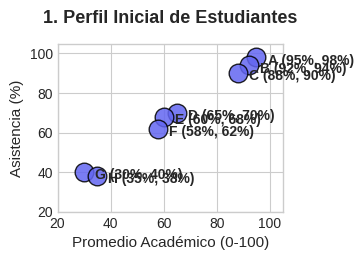

In [4]:
# ---------------------------------------------------------------------
# Subplot 1: Distribución Inicial de los Alumnos
# ---------------------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)
ax1.scatter(X[:, 0], X[:, 1], color='#6366f1', s=180, edgecolors='black', zorder=3, alpha=0.85)
for i, txt in enumerate(etiquetas):
    ax1.annotate(f"{txt} ({X[i,0]}%, {X[i,1]}%)", (X[i, 0], X[i, 1]),
                 xytext=(8, -5), textcoords='offset points', fontsize=10, fontweight='bold')
ax1.set_title("1. Perfil Inicial de Estudiantes", fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel("Promedio Académico (0-100)", fontsize=11)
ax1.set_ylabel("Asistencia (%)", fontsize=11)
ax1.set_xlim(20, 105)
ax1.set_ylim(20, 105)


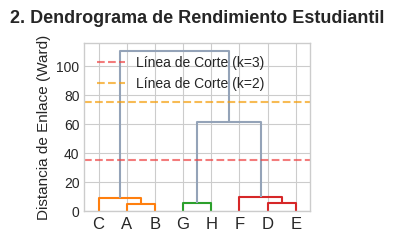

In [5]:
# ---------------------------------------------------------------------
# Subplot 2: Dendrograma (Enlace Completo / Ward)
# ---------------------------------------------------------------------
ax2 = plt.subplot(2, 2, 2)
# Usamos 'ward' para minimizar la varianza dentro de los clusters resultantes
Z = linkage(X, method='ward')
dendrogram(Z, labels=etiquetas, ax=ax2, color_threshold=35, above_threshold_color='#94a3b8')
ax2.set_title("2. Dendrograma de Rendimiento Estudiantil", fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel("Distancia de Enlace (Ward)", fontsize=11)
ax2.axhline(y=35, color='#ef4444', linestyle='--', alpha=0.7, label='Línea de Corte (k=3)')
ax2.axhline(y=75, color='#f59e0b', linestyle='--', alpha=0.7, label='Línea de Corte (k=2)')
ax2.legend(loc='upper left')


(20.0, 105.0)

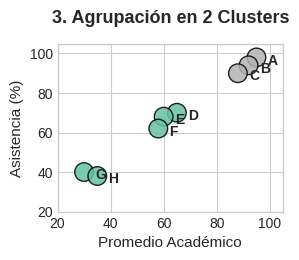

In [6]:
# ---------------------------------------------------------------------
# Subplot 3: Clasificación con 2 Clusters
# ---------------------------------------------------------------------
ax3 = plt.subplot(2, 2, 3)
hc_2 = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
clusters_2 = hc_2.fit_predict(X)

# Graficar los 2 clusters
ax3.scatter(X[:, 0], X[:, 1], c=clusters_2, cmap='Set2', s=180, edgecolors='black', zorder=3, alpha=0.85)
for i, txt in enumerate(etiquetas):
    ax3.annotate(txt, (X[i, 0], X[i, 1]), xytext=(8, -5), textcoords='offset points', fontsize=10, fontweight='bold')
ax3.set_title("3. Agrupación en 2 Clusters", fontsize=13, fontweight='bold', pad=15)
ax3.set_xlabel("Promedio Académico", fontsize=11)
ax3.set_ylabel("Asistencia (%)", fontsize=11)
ax3.set_xlim(20, 105)
ax3.set_ylim(20, 105)


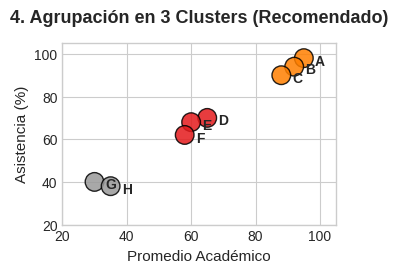

In [8]:
# ---------------------------------------------------------------------
# Subplot 4: Clasificación con 3 Clusters
# ---------------------------------------------------------------------
ax4 = plt.subplot(2, 2, 4)
hc_3 = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clusters_3 = hc_3.fit_predict(X)

# Graficar los 3 clusters
ax4.scatter(X[:, 0], X[:, 1], c=clusters_3, cmap='Set1', s=180, edgecolors='black', zorder=3, alpha=0.85)
for i, txt in enumerate(etiquetas):
    ax4.annotate(txt, (X[i, 0], X[i, 1]), xytext=(8, -5), textcoords='offset points', fontsize=10, fontweight='bold')
ax4.set_title("4. Agrupación en 3 Clusters (Recomendado)", fontsize=13, fontweight='bold', pad=15)
ax4.set_xlabel("Promedio Académico", fontsize=11)
ax4.set_ylabel("Asistencia (%)", fontsize=11)
ax4.set_xlim(20, 105)
ax4.set_ylim(20, 105)

plt.tight_layout()
plt.show()


In [9]:
# =====================================================================
# DIAGNÓSTICO DE ESCALAS (Información Técnica)
# =====================================================================
print("--- ANÁLISIS DE LAS ESCALAS EN EL EJERCICIO 3 ---")
print(f"Rango del 'Promedio Académico': {X[:, 0].min()} a {X[:, 0].max()} (Amplitud: {X[:, 0].max() - X[:, 0].min()})")
print(f"Rango de la 'Asistencia (%)': {X[:, 1].min()}% a {X[:, 1].max()}% (Amplitud: {X[:, 1].max() - X[:, 1].min()}%)")
print("\nComentario Técnico: A diferencia del Ejercicio 2, aquí ambas variables tienen rangos")
print("prácticamente idénticos (~65 y ~60). Las distancias euclidianas no se ven sesgadas")
print("por diferencias de magnitud, lo que hace que los clusters sean estables por naturaleza.")

--- ANÁLISIS DE LAS ESCALAS EN EL EJERCICIO 3 ---
Rango del 'Promedio Académico': 30 a 95 (Amplitud: 65)
Rango de la 'Asistencia (%)': 38% a 98% (Amplitud: 60%)

Comentario Técnico: A diferencia del Ejercicio 2, aquí ambas variables tienen rangos
prácticamente idénticos (~65 y ~60). Las distancias euclidianas no se ven sesgadas
por diferencias de magnitud, lo que hace que los clusters sean estables por naturaleza.


1. ¿Qué alumnos se parecen más?

Analizando la distribución de los datos y el dendrograma, identificamos que los alumnos más similares entre sí son:

Alumnos G y H (Caso Crítico): Tienen la mayor similitud de todo el conjunto de datos. Presentan calificaciones sumamente bajas ($30$ y $35$ de promedio) y una asistencia crítica ($40\%$ y $38\%$). La distancia euclidiana entre ellos es de apenas:


$$d(G, H) = \sqrt{(30 - 35)^2 + (40 - 38)^2} = \sqrt{25 + 4} = \sqrt{29} \approx 5.38$$

Alumnos A y B (Caso de Excelencia): Tienen un promedio sobresaliente ($95$ y $92$) y asistencias casi perfectas ($98\%$ y $94\%$). Su distancia es de solo $\approx 5.00$.

Alumnos D, E y F (Caso Regular): Forman un bloque muy compacto con calificaciones que van de $58$ a $65$ y asistencias regulares de $62\%$ a $70\%$.

2. ¿Qué perfiles de estudiantes aparecen?

Al agrupar a los estudiantes en la solución recomendada de $k = 3$, el algoritmo de clustering identifica tres arquetipos o perfiles muy claros:

Perfil / Clúster: C1

Nombre del Segmento: Estudiantes en Riesgo Académico (Alumnos A, B, C)

Comportamiento del Estudiante: Promedio: > 88 y Asistencia: > 90%

Diagnóstico Educativo: Estudiantes altamente constantes y motivados, con un excelente desempeño y asistencia impecable.

Perfil / Clúster: C2

Nombre del Segmento: Estudiantes en Riesgo Académico (Alumnos D, E, F)

Comportamiento del Estudiante: Promedio: 58 - 65 Asistencia: 62% - 70%

Diagnóstico Educativo: Alumnos con un rezago escolar moderado. Su inasistencia empieza a impactar directamente sus notas, pero es una situación reversible.

Perfil / Clúster: C3

Nombre del Segmento: Estudiantes Desconectados / Deserción (Alumnos G, H)

Comportamiento del Estudiante: Promedio: <35 Asistencia: <40%

Diagnóstico Educativo: Alumnos completamente desvinculados de la escuela. Su ausentismo es grave, lo que se traduce en reprobación automática si no se interviene.

3. ¿Qué decisión institucional podría tomarse con esta información?

Una institución educativa no debe aplicar la misma solución para problemas distintos. La segmentación permite diseñar planes de acción específicos:

Para el Grupo de Excelencia (C1): Implementar programas de tutorías (donde ellos apoyen a sus compañeros con rezago), becas de liderazgo escolar o actividades académicas de enriquecimiento curricular.

Para el Grupo en Riesgo Académico (C2): Ofrecer talleres obligatorios de regularización académica, planes flexibles para la entrega de tareas pendientes y seguimiento continuo por parte del tutor del grupo para motivar su asistencia regular.

Para el Grupo Desconectado (C3): Realizar una intervención social urgente. Es vital contactar a los padres de familia o tutores legales para diagnosticar si el ausentismo se debe a problemas de salud, familiares, económicos o emocionales. A este nivel, el apoyo académico no funciona si el alumno no se presenta a clases.

4. ¿Qué ocurre cuando el número de clusters cambia?

La elección del número de grupos ($k$) cambia la visibilidad del diagnóstico para la escuela:

Con $k = 3$ (Óptimo): Se tiene la visión más clara y accionable. Permite separar la desatención severa (que requiere ayuda familiar/social) del rezago escolar regular (que requiere regularización de contenidos de clase).

Con $k = 2$: El algoritmo se ve obligado a unir los dos grupos más cercanos del árbol. En este caso, fusiona el grupo de Riesgo Académico (C2) y el de Deserción (C3) en un solo gran bloque.

Consecuencia: Se pierde precisión diagnóstica. La escuela trataría con la misma estrategia al alumno que asiste al $70\%$ y tiene $65$ de promedio, que al alumno que falta casi siempre ($38\%$ de asistencia) y tiene un $35$ de calificación.

5. ¿Qué grupo requeriría más intervención académica y por qué?

El grupo que requiere la intervención más urgente, profunda y multifactorial es el grupo de Deserción / Desconectados (Alumnos G y H).

¿Por qué?

Gravedad: Con calificaciones menores al $35\%$, están pedagógicamente muy lejos del puntaje mínimo aprobatorio.

Foco del Problema: Su inasistencia es de más del $60\%$. Esto nos indica que el problema principal no es de aprendizaje (que no entiendan la materia), sino de permanencia escolar (no están asistiendo a la escuela).

Límite Administrativo: En la mayoría de los reglamentos escolares, una asistencia por debajo del $80\%$ o $75\%$ anula automáticamente el derecho a acreditar la materia, por lo que administrativamente están reprobados si no se realiza un rescate formal a tiempo.